In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
path=r"C:\Users\292593\Desktop\master\python training\python_code_submit\Python-training\loan_amount_prediction_dataset_v2.csv"

In [3]:
df= pd.read_csv(path)

In [4]:
df.head()

,Age,Monthly_Income,Credit_Score,Loan_Tenure_Years,Existing_Loan_Amount,Num_of_Dependents,Loan_Amount
0,29,31515,777,16,465920,4,-31410
1,45,143962,722,22,253462,4,32523
2,24,122858,467,29,188059,2,35972
3,44,79131,813,26,452969,0,28036
4,36,112300,519,16,121038,3,51783


In [5]:
df. dtypes

Age                     int64
Monthly_Income          int64
Credit_Score            int64
Loan_Tenure_Years       int64
Existing_Loan_Amount    int64
Num_of_Dependents       int64
Loan_Amount             int64
dtype: object

# Checking data 

In [6]:
df.shape

(500, 7)

In [7]:
df.describe()

,Age,Monthly_Income,Credit_Score,Loan_Tenure_Years,Existing_Loan_Amount,Num_of_Dependents,Loan_Amount
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,40.416000,84094.666000,583.698000,14.76200,254092.894000,1.958000,24562.796000
std,11.345677,36555.333098,160.775646,8.23681,147439.271452,1.384221,19119.245983
min,21.000000,20422.000000,300.000000,1.00000,931.000000,0.000000,-31410.000000
25%,31.000000,51825.750000,445.750000,8.00000,125872.750000,1.000000,11944.250000
50%,40.000000,83810.500000,593.000000,14.00000,254272.000000,2.000000,24996.000000
75%,50.000000,115955.250000,731.250000,22.00000,394601.500000,3.000000,38588.750000
max,59.000000,149918.000000,849.000000,29.00000,499527.000000,4.000000,86823.000000


In [8]:
df.isna().sum()

Age                     0
Monthly_Income          0
Credit_Score            0
Loan_Tenure_Years       0
Existing_Loan_Amount    0
Num_of_Dependents       0
Loan_Amount             0
dtype: int64

In [9]:
df.head()

,Age,Monthly_Income,Credit_Score,Loan_Tenure_Years,Existing_Loan_Amount,Num_of_Dependents,Loan_Amount
0,29,31515,777,16,465920,4,-31410
1,45,143962,722,22,253462,4,32523
2,24,122858,467,29,188059,2,35972
3,44,79131,813,26,452969,0,28036
4,36,112300,519,16,121038,3,51783


In [11]:
df.columns

Index(['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
       'Existing_Loan_Amount', 'Num_of_Dependents', 'Loan_Amount'],
      dtype='object')

# Preprocessing Steps

In [12]:
print(df[df['Loan_Amount'] < 0])

     Age  Monthly_Income  Credit_Score  Loan_Tenure_Years  \
0     29           31515           777                 16   
16    30           46591           759                 27   
22    52           59042           368                  7   
25    40          104351           696                 18   
46    38           35954           722                  5   
53    48           34182           689                 15   
73    55           57618           687                 21   
85    56           58804           745                 22   
89    46           69983           332                  8   
103   43           34425           619                 26   
106   49           26203           374                 16   
117   49           21892           446                  2   
118   21           20884           785                 25   
120   49           29115           311                  7   
158   34           32540           422                 12   
160   46           45370

In [13]:
# Remove negative Loan_Amount values
df = df[df['Loan_Amount'] >= 0]


# EDA

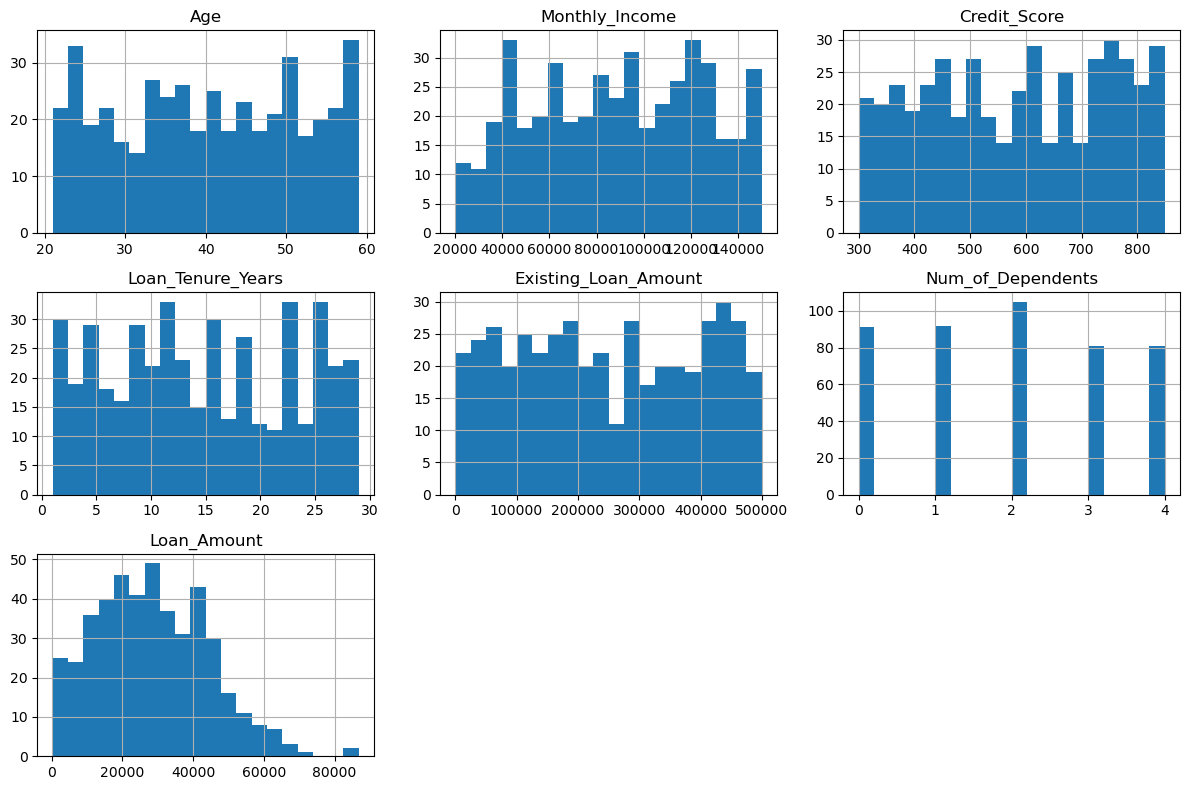

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for each feature
df.hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()


# Checking Correlations

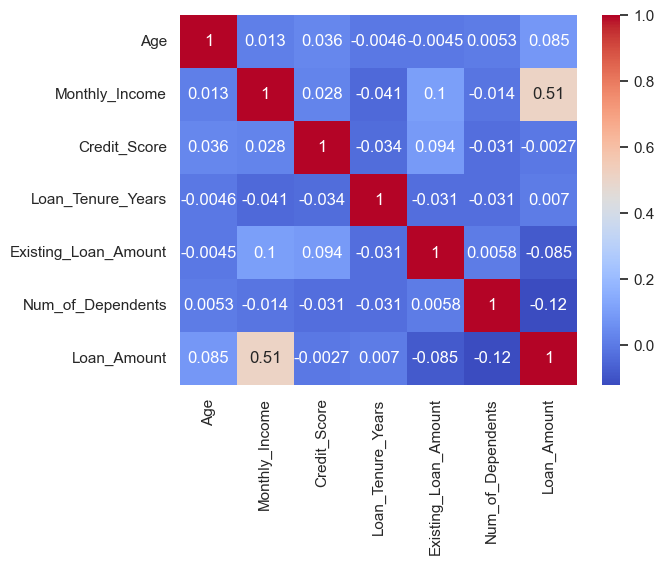

In [33]:
# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


# Scatter Plots vs Target
#Helps identify linear/non-linear relationships:

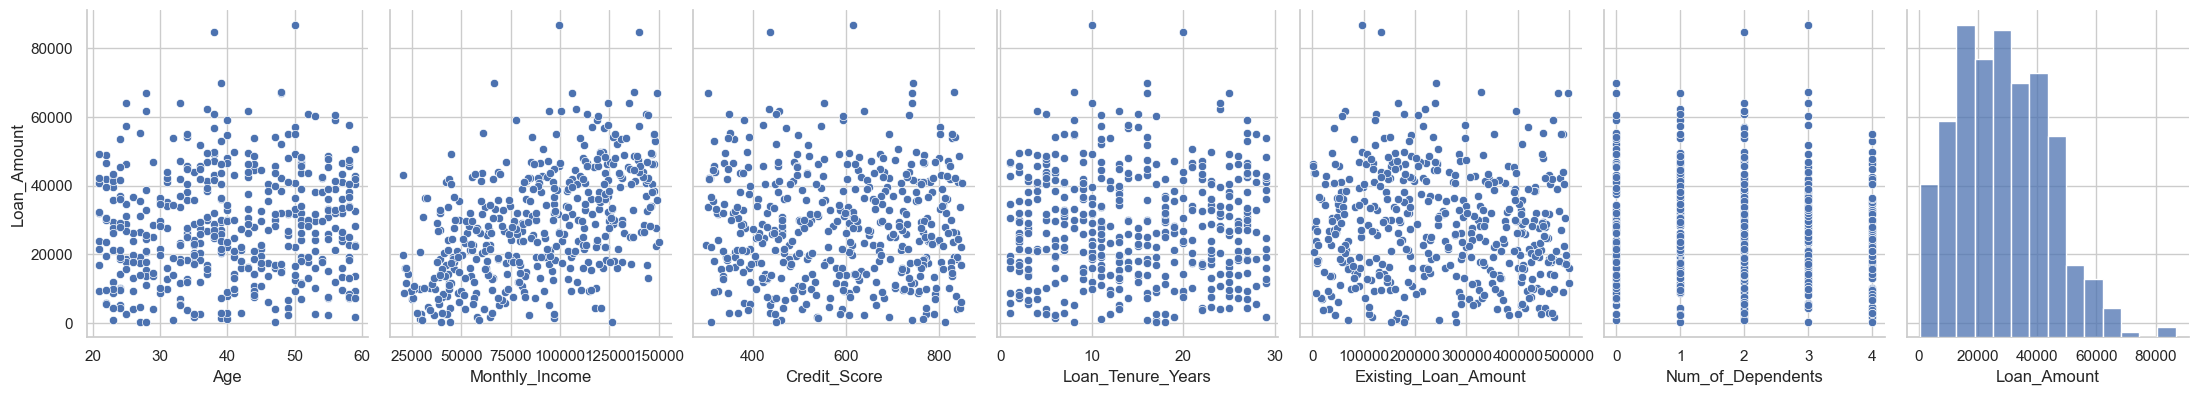

In [34]:
sns.pairplot(df, x_vars=df.columns, y_vars='Loan_Amount', height=4, aspect=0.8)
plt.show()


# Detect Outliers

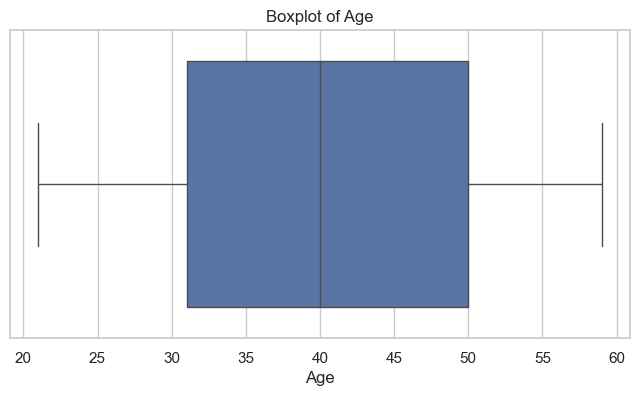

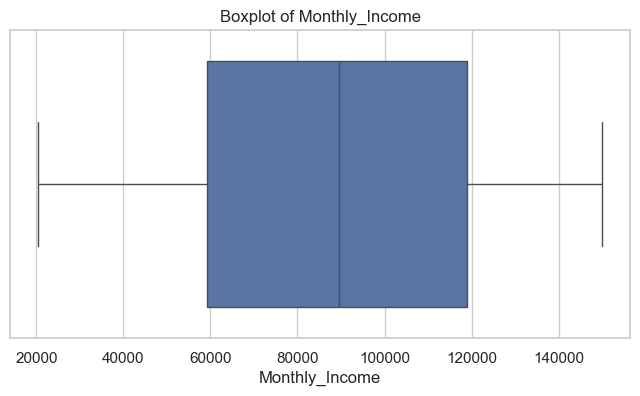

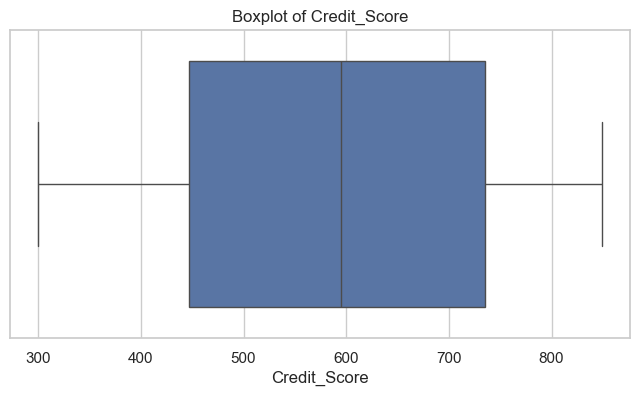

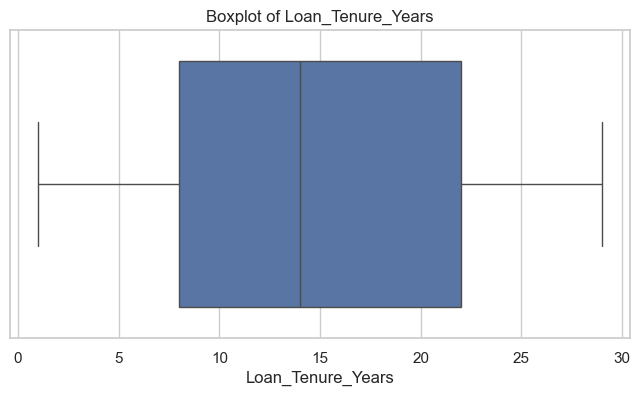

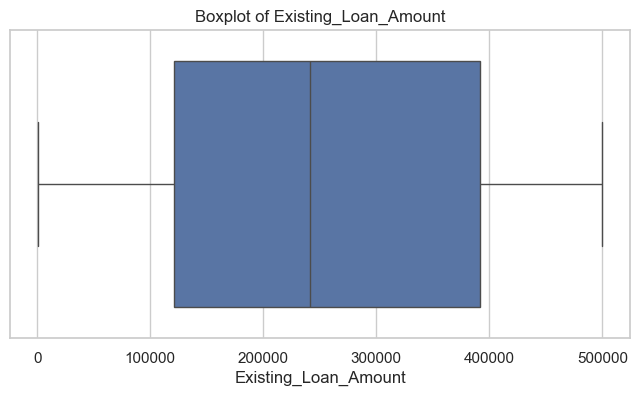

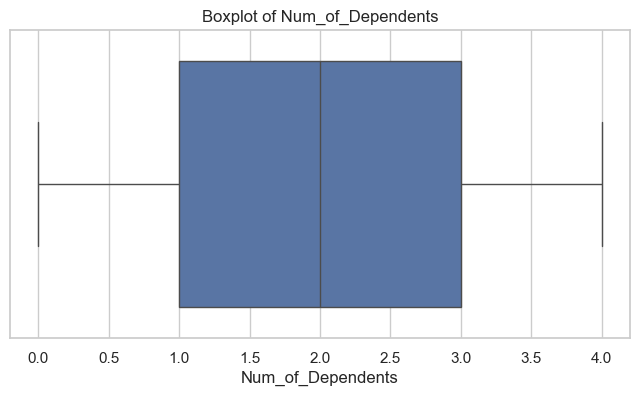

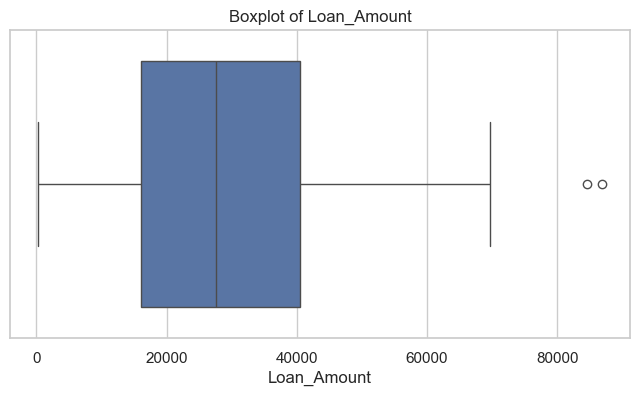

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# List of numerical features to check for outliers
features = ['Age', 'Monthly_Income', 'Credit_Score', 'Loan_Tenure_Years',
            'Existing_Loan_Amount', 'Num_of_Dependents', 'Loan_Amount']

# Plot each feature
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()


In [18]:
print(df.skew())


Age                    -0.013480
Monthly_Income         -0.066156
Credit_Score           -0.058814
Loan_Tenure_Years       0.093910
Existing_Loan_Amount    0.025749
Num_of_Dependents       0.073269
Loan_Amount             0.413395
dtype: float64


Skewness Analysis:

Age                         -0.01   → Symmetrical
Monthly_Income              -0.07   → Symmetrical
Credit_Score                -0.06   → Symmetrical
Loan_Tenure_Years            0.09   → Symmetrical
Existing_Loan_Amount         0.03   → Symmetrical
Num_of_Dependents            0.07   → Symmetrical
Loan_Amount                  0.41   → Symmetrical


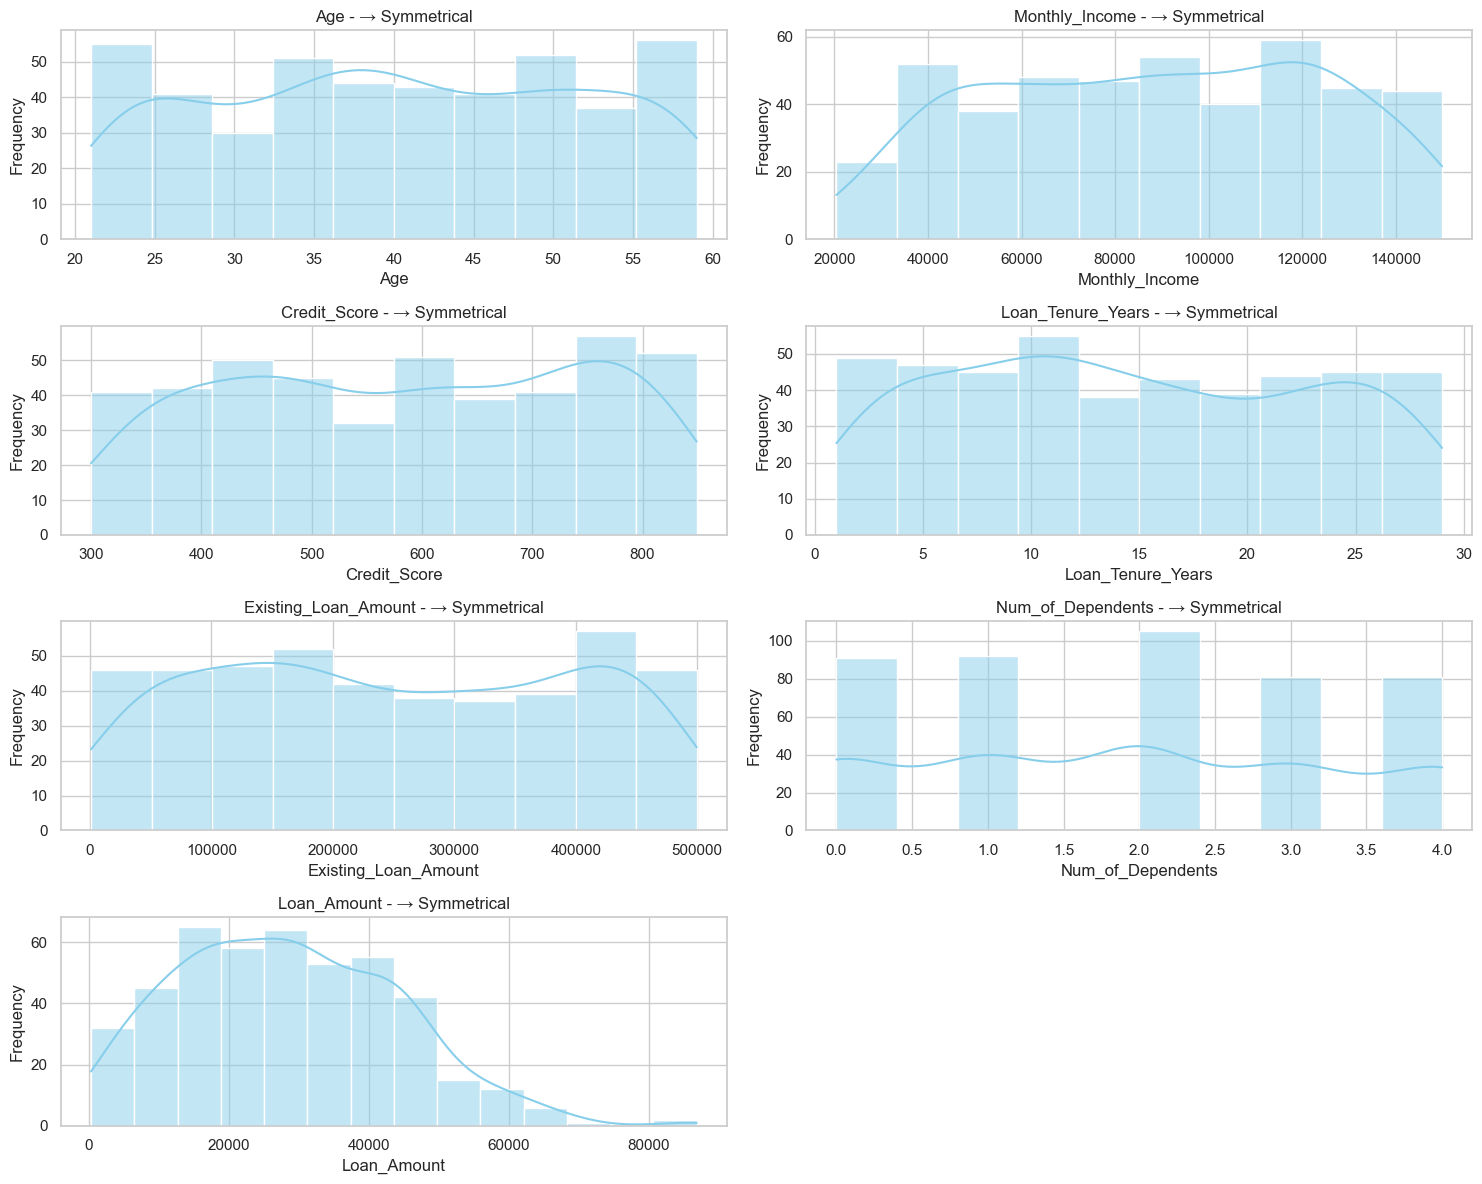

In [19]:
skew_vals = df.skew(numeric_only=True)

# Interpretation function
def interpret_skew(skew):
    if -0.5 <= skew <= 0.5:
        return "→ Symmetrical"
    elif skew > 1:
        return "→ Strong right skew"
    elif skew > 0.5:
        return "→ Moderately right skewed"
    elif skew > 0:
        return "→ Right skewed"
    elif skew < -1:
        return "→ Strong left skew"
    elif skew < -0.5:
        return "→ Moderately left skewed"
    else:
        return "→ Slight left skew"

# Create a result DataFrame
skew_summary = pd.DataFrame({
    'Feature': skew_vals.index,
    'Skewness': skew_vals.values,
    'Interpretation': [interpret_skew(s) for s in skew_vals.values]
})

# Print summary
print("Skewness Analysis:\n")
for _, row in skew_summary.iterrows():
    print(f"{row['Feature']:25s} {row['Skewness']:>7.2f}   {row['Interpretation']}")

# Plot histograms with KDE for visualization
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))
for i, col in enumerate(skew_vals.index):
    plt.subplot(4, 2, i + 1)
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f"{col} - {interpret_skew(df[col].skew())}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Indentified Predctors and Target

In [20]:
 # predictors
X = df.drop('Loan_Amount', axis=1)
# target
y = df['Loan_Amount']

In [21]:
# Using Standard scaler to feature scale the predictors

In [22]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled

array([[ 0.4091743 ,  1.57345986,  0.84328505,  0.88463533,  0.02715613,
         1.49754924],
       [-1.4173241 ,  0.97346584, -0.73405993,  1.72752743, -0.41729469,
         0.04986469],
       [ 0.32219818, -0.26970789,  1.40618071,  1.36628796,  1.38292041,
        -1.39781986],
       ...,
       [ 0.4091743 ,  1.3799345 , -1.68046692, -1.04197519, -0.05080947,
        -0.67397759],
       [ 1.27893544, -1.06948194,  1.57937938, -1.52362782, -1.49427061,
         1.49754924],
       [ 0.32219818,  1.4236888 ,  1.58556504, -1.16238835, -0.15158781,
        -0.67397759]])

In [24]:
df_scaled=pd.DataFrame(X_scaled,columns=X.columns)

In [25]:
df_scaled

,Age,Monthly_Income,Credit_Score,Loan_Tenure_Years,Existing_Loan_Amount,Num_of_Dependents
0,0.409174,1.573460,0.843285,0.884635,0.027156,1.497549
1,-1.417324,0.973466,-0.734060,1.727527,-0.417295,0.049865
2,0.322198,-0.269708,1.406181,1.366288,1.382920,-1.397820
3,-0.373611,0.673298,-0.412405,0.162156,-0.872741,0.773707
4,-0.808491,-1.683919,0.224718,-0.560323,-1.184345,-0.673978
...,...,...,...,...,...,...
445,0.583127,0.173009,0.453588,1.486701,1.000839,-0.673978
446,0.670103,1.341326,-0.647461,0.884635,-0.769917,0.773707
447,0.409174,1.379934,-1.680467,-1.041975,-0.050809,-0.673978
448,1.278935,-1.069482,1.579379,-1.523628,-1.494271,1.497549


# spliting into test and train dataset

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# You can also check the shape of the splits to verify
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 360
Test set size: 90


# Training Models 

In [27]:
# Initialize the model
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_linear = linear_reg_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear).round(3)
r2_linear = r2_score(y_test, y_pred_linear).round(3)

print("Linear Regression Model:")
print(f"Mean Squared Error: {mse_linear}")
print(f"R-squared: {r2_linear}")

Linear Regression Model:
Mean Squared Error: 217980679.922
R-squared: 0.282


# Random Forest Regressor

In [31]:
# Initialize the model
rf_model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1, max_depth=10, min_samples_split=5)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf).round(3)
r2_rf = r2_score(y_test, y_pred_rf).round(3)

print("Random Forest Regressor Model:")
print(f"Mean Squared Error: {mse_rf}")
print(f"R-squared: {r2_rf}")

Random Forest Regressor Model:
Mean Squared Error: 252952728.616
R-squared: 0.167


# Evaluating models 

In [32]:
import pandas as pd

# Disable scientific notation
pd.set_option('display.float_format', '{:,.3f}'.format)

# Create comparison table
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'Mean Squared Error': [round(mse_linear, 3), round(mse_rf, 3), round(mse_gb, 3)],
    'R-squared': [round(r2_linear, 3), round(r2_rf, 3), round(r2_gb, 3)]
})

# Sort and show
model_comparison.sort_values(by='R-squared', ascending=False, inplace=True)
model_comparison


,Model,Mean Squared Error,R-squared
0,Linear Regression,"217,980,679.922",0.282
1,Random Forest Regressor,"252,952,728.616",0.167
2,Gradient Boosting Regressor,"258,292,022.230",0.149


#  Despite slightly lower R² in testing, we chose Random Forest Regressor for its interpretability, stability, non-linear modeling capability, and robustness. With proper hyperparameter tuning, it offers a balanced tradeoff between bias and variance, which is essential in financial predictions.